In [121]:
# import cellpose as cp
from pathlib import Path
import numpy as np
import rasterio
import tifffile
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Polygon
from skimage.measure import find_contours
import pandas as pd
import napari
import seaborn as sns
# %gui qt

In [2]:
def find_tissue_edges(image, smoothing_window_size=100, downsample_size=100):
    """ Finds the tissue edges in a 2D image by analyzing the summed pixel values along each axis.
    Args:
        image (np.ndarray): 2D array representing the image - better to be binarized.
        smoothing_window_size (int): Size of the smoothing window for convolution.
        downsample_size (int): Factor by which to downsample the data.
    Returns:
        tuple: Two tuples containing the x and y coordinates of the tissue edges.
    """
    for i in range(2):
        temp = image.sum(axis=i)
        smoothed = np.convolve(temp, np.ones(smoothing_window_size) / smoothing_window_size, mode='valid')
        downsampled = smoothed[::downsample_size]
        ds_diff = np.diff(downsampled)**2
        diff_std = np.std(ds_diff)
    
        temp_min = max((np.where(ds_diff > diff_std)[0][0]-1) * downsample_size - smoothing_window_size, 0)
        temp_max = min((np.where(ds_diff > diff_std)[0][-1] + 2) * downsample_size + smoothing_window_size, image.shape[i])

        if i == 0:
            x_min, x_max = temp_min, temp_max
        else:
            y_min, y_max = temp_min, temp_max

    return (x_min, x_max), (y_min, y_max)
    

In [4]:
tc_link_fn = r"C:\Users\jinho.kim\OneDrive - Allen Institute\Analysis\Pilot\GCaMP validation\tissuecyte_link.csv"
tc_link = pd.read_csv(tc_link_fn)

In [32]:
tc_link

,gcamp,mouse_id,Storage directory
0,Slc32a1;Oi1,767017,\\allen\programs\mindscope\production\learning...
1,Slc32a1;Oi1,767023,\\allen\programs\mindscope\production\learning...
2,Slc32a1;Oi4,753561,\\allen\programs\mindscope\production\learning...
3,Slc32a1;Oi4,753562,\\allen\programs\mindscope\production\learning...
4,Slc32a1;Oi4,758265,\\allen\programs\mindscope\production\learning...
5,SNAP25;Oi4 (dox),755212,\\allen\programs\mindscope\production\learning...
6,SNAP25;Oi4 (dox),773630,\\allen\programs\mindscope\production\learning...
7,Oi4+/+ +iCre,741863,\\allen\programs\mindscope\production\learning...
8,Oi4+/+ +iCre,759730,\\allen\programs\mindscope\production\learning...
9,Oi4+/+ +iCre,759731,\\allen\programs\mindscope\production\learning...


In [4]:
def process_image(mouse_id, filepath,
                downsample_rate=20,
                save_dir=Path(r'D:\GCaMP characterization\tissuecyte')):
    """ Processes a single image file to save the tissue part (tif and downsampled png).
    Args:
        mouse_id (str): Identifier for the mouse.
        filepath (str): Path to the image file.
        save_dir (Path): Directory where the processed image will be saved.    
    """
    with rasterio.open(filepath) as src:
        image = src.read(2)
    
    # Binarize the image if necessary
    thresholded_image = image > np.percentile(image, 80)
    # Find tissue edges
    tissue_edges = find_tissue_edges(thresholded_image)
    tissue_image = image[tissue_edges[1][0]:tissue_edges[1][1], tissue_edges[0][0]:tissue_edges[0][1]]

    save_dir.mkdir(parents=True, exist_ok=True)
    save_fn = save_dir / f'{mouse_id}.tiff'
    tifffile.imwrite(save_fn, tissue_image)

    # save downsampled png
    downsampled_img = tissue_image[::downsample_rate, ::downsample_rate]
    vmax = np.percentile(downsampled_img, 99.8)
    downsampled_fn = save_dir / f'{mouse_id}_downsampled.png'
    plt.imsave(downsampled_fn, downsampled_img, cmap='gray', vmin=0, vmax=vmax)


In [7]:
for _, row in tc_link.iloc[7:].iterrows():    
    mouse_id = row['mouse_id']
    filepath = Path(row['Storage directory'])
    process_image(mouse_id, filepath)
    print(f'Processing done for {mouse_id}')
# 27 minutes for 15 images (~1.8 minutes per image)

c:\Users\jinho.kim\Anaconda3\envs\cellpose\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Processing done for 741863
Processing done for 759730
Processing done for 759731
Processing done for 762818
Processing done for 762819
Processing done for 750447
Processing done for 750451
Processing done for 735170
Processing done for 735169


# Crop

In [39]:
save_dir = Path(r'D:\GCaMP characterization\tissuecyte')

row_i = 10
row = tc_link.iloc[row_i]
mouse_id = row['mouse_id']
section_tiff_fn = save_dir / f'{mouse_id}.tiff'
section_png_fn = save_dir / f'{mouse_id}_downsampled.png'
section_img = tifffile.imread(section_tiff_fn)
# with rasterio.open(section_png_fn) as src:
#     section_img = src.read(1)
# print(mouse_id)

viewer = napari.Viewer()
viewer.add_image(section_img, name=mouse_id, colormap='gray', contrast_limits=(0, np.percentile(section_img, 99.8)))

<Image layer '762818' at 0x1b2147fe710>

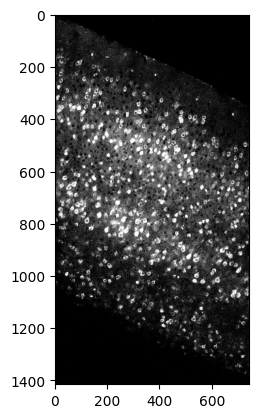

In [37]:
# manually select (y1, x1) and (y2, x2) for cropping
# %matplotlib inline
# hemisphere = 'left'
hemisphere = 'right'

y1, x1 = 666, 8281
y2, x2 = 2081, 9023
xmin, xmax = min(x1, x2), max(x1, x2)
ymin, ymax = min(y1, y2), max(y1, y2)
crop_img = section_img[ymin:ymax, xmin:xmax]

fig, ax = plt.subplots()
ax.imshow(crop_img, vmax=np.percentile(crop_img, 98), cmap='gray')


In [38]:
# save crop_image and xy coordinates
crop_image_fn = save_dir / f'{mouse_id}_crop_{hemisphere}.tif'
tifffile.imwrite(crop_image_fn, crop_img)
crop_coords_fn = save_dir / f'{mouse_id}_crop_{hemisphere}_coords.npy'
np.save(crop_coords_fn, np.array([xmin, xmax, ymin, ymax]))


# Run CellPose-SAM using GUI

# Analyzing the result masks
- Manually curated in cp-sam
- Still need more filtering (edge, small)
- First check left vs right when the animal got cranial window.
- If imaging does not seem to have affected brightness, then compare left hemisphere from all animals.
- Brightness & overall density
- Then think about layer differences

In [10]:
# example
save_dir = Path(r'D:\GCaMP characterization\tissuecyte')

mouse_id = 741863
hemisphere = 'left'
cp_results_fn = save_dir / f'{mouse_id}_crop_{hemisphere}_seg.npy'
cp_results = np.load(cp_results_fn, allow_pickle=True).item()

crop_image = tifffile.imread(save_dir / f'{mouse_id}_crop_{hemisphere}.tif')

In [7]:
cp_results.keys()

dict_keys(['outlines', 'colors', 'masks', 'filename', 'flows', 'ismanual', 'manual_changes', 'model_path', 'flow_threshold', 'cellprob_threshold', 'normalize_params', 'restore', 'ratio', 'diameter'])

In [22]:
num_rois = cp_results['masks'].max()
edge_mask = np.zeros(crop_image.shape, dtype=bool)
edge_mask[0,:] = True
edge_mask[-1,:] = True
edge_mask[:,0] = True
edge_mask[:,-1] = True

brightness = []
valid_roi_ids = []
for roi_id in range(1, num_rois + 1):
    roi_mask = cp_results['masks'] == roi_id
    # pass if overlap with edge mask
    if np.any(roi_mask & edge_mask):
        continue
    # pass if too small (equivalent to 4 um in diameter, 1 pixel = 0.875 um)
    if roi_mask.sum() < (4/0.875/2)**2 * np.pi:
        continue

    roi_brightness = crop_image[roi_mask].mean()
    brightness.append(roi_brightness)
    valid_roi_ids.append(roi_id)    

Text(0.5, 1.0, 'Valid contours')

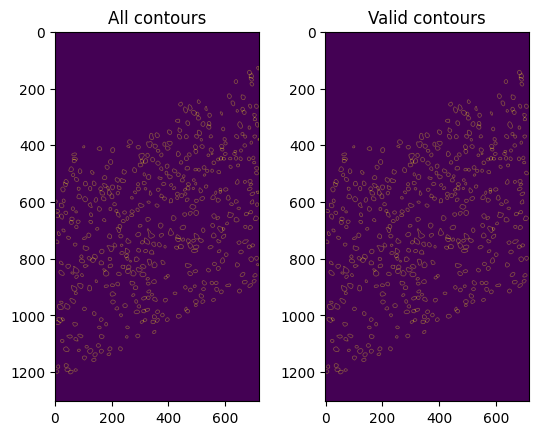

In [23]:
all_contours = cp_results['outlines'] > 0
valid_contours = np.zeros_like(all_contours, dtype=bool)
for roi_id in valid_roi_ids:
    valid_contours |= cp_results['outlines'] == roi_id
fig, ax = plt.subplots(1, 2)
ax[0].imshow(all_contours)
ax[0].set_title('All contours')
ax[1].imshow(valid_contours)
ax[1].set_title('Valid contours')


In [24]:
def get_brightness(mouse_id, hemisphere, save_dir=Path(r'D:\GCaMP characterization\tissuecyte')):
    """ Computes the brightness of each ROI in the segmented image.
    Args:
        mouse_id (str): Identifier for the mouse.
        hemisphere (str): Hemisphere identifier ('left' or 'right').
        save_dir (Path): Directory where the processed images are saved.
    Returns:
        np.ndarray: Array of brightness values for each ROI.
    """
    cp_results_fn = save_dir / f'{mouse_id}_crop_{hemisphere}_seg.npy'
    cp_results = np.load(cp_results_fn, allow_pickle=True).item()
    
    crop_image = tifffile.imread(save_dir / f'{mouse_id}_crop_{hemisphere}.tif')
    
    num_rois = cp_results['masks'].max()
    
    edge_mask = np.zeros(crop_image.shape, dtype=bool)
    edge_mask[0,:] = True
    edge_mask[-1,:] = True
    edge_mask[:,0] = True
    edge_mask[:,-1] = True

    brightness = []
    valid_roi_ids = []
    for roi_id in range(1, num_rois + 1):
        roi_mask = cp_results['masks'] == roi_id
        # pass if overlap with edge mask
        if np.any(roi_mask & edge_mask):
            continue
        # pass if too small (equivalent to 4 um in diameter, 1 pixel = 0.875 um)
        if roi_mask.sum() < (4/0.875/2)**2 * np.pi:
            continue

        roi_brightness = crop_image[roi_mask].mean()
        brightness.append(roi_brightness)
        valid_roi_ids.append(roi_id)
    brightness = np.array(brightness)
    valid_roi_ids = np.array(valid_roi_ids)    
    return brightness, valid_roi_ids


In [25]:
# first, process them all
hemispheres = ['left', 'right']
for _, row in tc_link.iterrows():    
    mouse_id = row['mouse_id']
    for hemisphere in hemispheres:
        if not (save_dir / f'{mouse_id}_crop_{hemisphere}.tif').exists():
            print(f'Skipping {mouse_id} {hemisphere}: crop image not found.')
            continue
        if not (save_dir / f'{mouse_id}_crop_{hemisphere}_seg.npy').exists():
            print(f'Skipping {mouse_id} {hemisphere}: segmentation results not found.')
            continue
        
        # Get brightness values
        brightness, valid_roi_ids = get_brightness(mouse_id, hemisphere)
        print(f'Processed {mouse_id} {hemisphere}: {len(valid_roi_ids)} ROIs found with brightness values.')
        # Save brightness values
        brightness_fn = save_dir / f'{mouse_id}_crop_{hemisphere}_brightness.npy'
        results = {
            'brightness': brightness,
            'valid_roi_ids': valid_roi_ids
        }
        np.save(brightness_fn, results)
        


Processed 767017 left: 172 ROIs found with brightness values.
Processed 767017 right: 120 ROIs found with brightness values.
Processed 767023 left: 108 ROIs found with brightness values.
Processed 767023 right: 150 ROIs found with brightness values.
Processed 753561 left: 138 ROIs found with brightness values.
Processed 753561 right: 168 ROIs found with brightness values.
Processed 753562 left: 156 ROIs found with brightness values.
Processed 753562 right: 185 ROIs found with brightness values.
Processed 758265 left: 132 ROIs found with brightness values.
Skipping 758265 right: crop image not found.
Processed 755212 left: 876 ROIs found with brightness values.
Processed 755212 right: 1388 ROIs found with brightness values.
Processed 773630 left: 1370 ROIs found with brightness values.
Processed 773630 right: 1507 ROIs found with brightness values.
Processed 741863 left: 454 ROIs found with brightness values.
Processed 741863 right: 779 ROIs found with brightness values.
Processed 75973

In [26]:
implanted_mouse_ids = [741863, 753561, 753562, 755212, 759730, 759731] # 758265 removed due to right hemisphere gone
left_median_brightness = []
right_median_brightness = []
for mouse_id in implanted_mouse_ids:
    left_brightness_fn = save_dir / f'{mouse_id}_crop_left_brightness.npy'
    right_brightness_fn = save_dir / f'{mouse_id}_crop_right_brightness.npy'
    
    if not left_brightness_fn.exists() or not right_brightness_fn.exists():
        print(f'Skipping {mouse_id}: brightness files not found.')
        continue
    
    left_results = np.load(left_brightness_fn, allow_pickle=True).item()
    right_results = np.load(right_brightness_fn, allow_pickle=True).item()
    
    left_median_brightness.append(np.median(left_results['brightness']))
    right_median_brightness.append(np.median(right_results['brightness']))


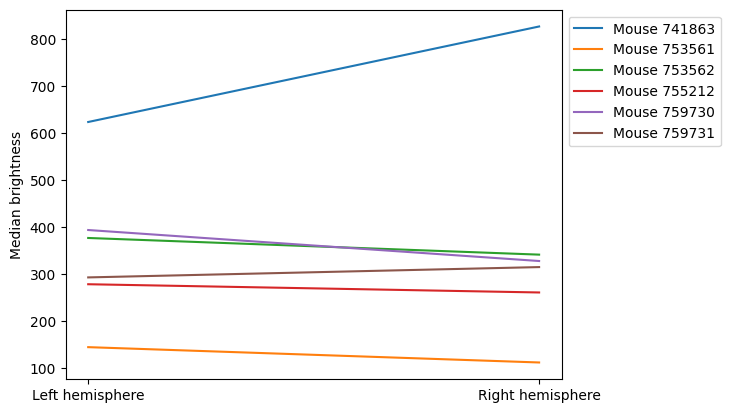

In [29]:
fig, ax = plt.subplots()
for i in range(len(implanted_mouse_ids)):
    ax.plot([0, 1], [left_median_brightness[i], right_median_brightness[i]], label= f'Mouse {implanted_mouse_ids[i]}')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Left hemisphere', 'Right hemisphere'])
ax.set_ylabel('Median brightness')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))


## No sign of bleaching on the left side. 
- Proceed with left hemisphere analysis.

In [292]:
inhib_palette = {'Slc32a1;Oi1': 'aqua', 'Slc32a1;Oi4': 'C0'}
panneuronal_palette =  {'SNAP25;Oi4 (dox)': 'r', 'Oi4+/+ +iCre': 'orchid'}
inhib_order = list(inhib_palette.keys())
panneuronal_order = list(panneuronal_palette.keys())

In [40]:
hemisphere = 'left'
brightness_df = pd.DataFrame(columns=['gcamp', 'mouse_id', 'brightness'])
for inhib in inhib_order:
    inhib_df = tc_link[tc_link['gcamp'] == inhib]
    for mouse_id in inhib_df['mouse_id']:
        brightness_fn = save_dir / f'{mouse_id}_crop_{hemisphere}_brightness.npy'
        if not brightness_fn.exists():
            print(f'Skipping {mouse_id}: brightness file not found.')
            continue
        results = np.load(brightness_fn, allow_pickle=True).item()
        brightness = results['brightness']
        temp_df = pd.DataFrame({
            'gcamp': inhib,
            'mouse_id': mouse_id,
            'brightness': [brightness]
        })
        brightness_df = pd.concat([brightness_df, temp_df], ignore_index=True)
for panneuronal in panneuronal_order:
    panneuronal_df = tc_link[tc_link['gcamp'] == panneuronal]
    for mouse_id in panneuronal_df['mouse_id']:
        brightness_fn = save_dir / f'{mouse_id}_crop_{hemisphere}_brightness.npy'
        if not brightness_fn.exists():
            print(f'Skipping {mouse_id}: brightness file not found.')
            continue
        results = np.load(brightness_fn, allow_pickle=True).item()
        brightness = results['brightness']
        temp_df = pd.DataFrame({
            'gcamp': panneuronal,
            'mouse_id': mouse_id,
            'brightness': [brightness]
        })
        brightness_df = pd.concat([brightness_df, temp_df], ignore_index=True)

In [44]:
brightness_df

,gcamp,mouse_id,brightness
0,Slc32a1;Oi1,767017,"[1893.5875, 1139.5497076023391, 1143.162162162..."
1,Slc32a1;Oi1,767023,"[703.7028985507246, 1995.4697986577182, 1369.0..."
2,Slc32a1;Oi4,753561,"[204.43333333333334, 61.96363636363636, 93.775..."
3,Slc32a1;Oi4,753562,"[148.6504854368932, 247.98445595854923, 354.37..."
4,Slc32a1;Oi4,758265,"[165.05729166666666, 161.74534161490683, 62.38..."
5,SNAP25;Oi4 (dox),755212,"[95.63243243243244, 153.68333333333334, 105.56..."
6,SNAP25;Oi4 (dox),773630,"[253.32478632478632, 124.97021276595744, 51.52..."
7,Oi4+/+ +iCre,741863,"[369.7897435897436, 325.73262032085563, 596.05..."
8,Oi4+/+ +iCre,759730,"[291.54545454545456, 315.44444444444446, 277.7..."
9,Oi4+/+ +iCre,759731,"[177.3582554517134, 232.2560975609756, 112.322..."


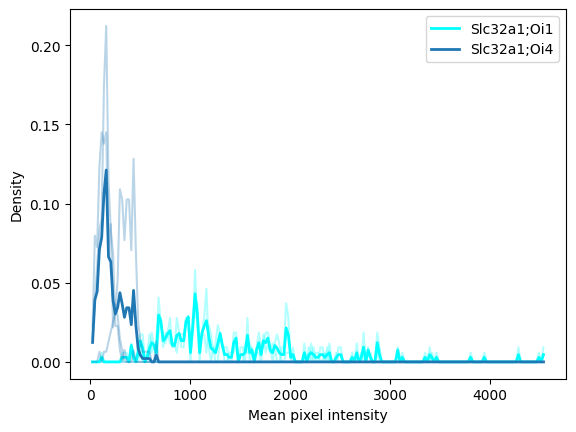

In [45]:
# inhibitory
inhib_df = brightness_df[brightness_df['gcamp'].isin(inhib_order)]
min_brightness = inhib_df['brightness'].apply(min).min()
max_brightness = inhib_df['brightness'].apply(max).max()
bins = np.linspace(np.floor(min_brightness), np.ceil(max_brightness), 200)
fig, ax = plt.subplots()
for inhib in inhib_order:
    temp_df = inhib_df[inhib_df['gcamp'] == inhib]
    all_inhib = []
    for _, row in temp_df.iterrows():
        brightness = np.array(row['brightness'])
        dist = np.histogram(brightness, bins=bins)[0] / len(brightness)
        ax.plot(bins[:-1], dist, alpha=0.3, color=inhib_palette[inhib])
        all_inhib.append(dist)
    ax.plot(bins[:-1], np.mean(all_inhib, axis=0), label=inhib, color=inhib_palette[inhib], linewidth=2)
ax.set_xlabel('Mean pixel intensity')
ax.set_ylabel('Density')
ax.legend()

C:\Users\jinho.kim\AppData\Local\Temp\ipykernel_22320\310103358.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slc32a1_oi4_df['brightness'] = slc32a1_oi4_df['brightness'].apply(lambda x: np.array(x))


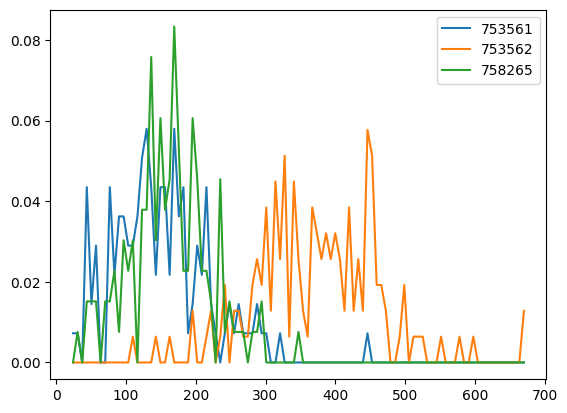

In [50]:
# Find the one that is most different among slc32a1;oi4
slc32a1_oi4_df = brightness_df[brightness_df['gcamp'] == 'Slc32a1;Oi4']
slc32a1_oi4_df['brightness'] = slc32a1_oi4_df['brightness'].apply(lambda x: np.array(x))
bins = np.linspace(np.floor(slc32a1_oi4_df['brightness'].apply(min).min()),
                     np.ceil(slc32a1_oi4_df['brightness'].apply(max).max()), 100)

fig, ax = plt.subplots()
for _, row in slc32a1_oi4_df.iterrows():
    brightness = np.array(row['brightness'])
    dist = np.histogram(brightness, bins=bins)[0] / len(brightness)
    ax.plot(bins[:-1], dist, label=f"{row['mouse_id']}")
ax.legend()

C:\Users\jinho.kim\AppData\Local\Temp\ipykernel_22320\3502136102.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Slc32a1;Oi1', 'Slc32a1;Oi4'])


Text(0, 0.5, 'Mean ROI intensity')

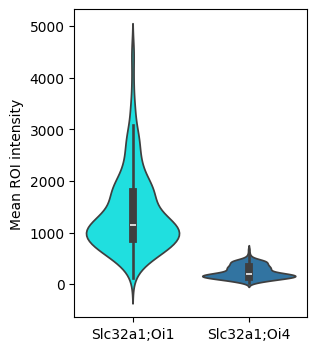

In [57]:
# pool all the neurons
brightness_oi1 = []
brightness_oi4 = []
for _, row in inhib_df[inhib_df['gcamp'] == 'Slc32a1;Oi1'].iterrows():
    brightness_oi1.append(np.array(row['brightness']))
for _, row in inhib_df[inhib_df['gcamp'] == 'Slc32a1;Oi4'].iterrows():
    brightness_oi4.append(np.array(row['brightness']))
brightness_oi1 = np.concatenate(brightness_oi1)
brightness_oi4 = np.concatenate(brightness_oi4)
fig, ax = plt.subplots(figsize=(3,4))
sns.violinplot(data=[brightness_oi1, brightness_oi4], ax=ax, palette=['aqua', 'C0'])
ax.set_xticklabels(['Slc32a1;Oi1', 'Slc32a1;Oi4'])
ax.set_ylabel('Mean ROI intensity')


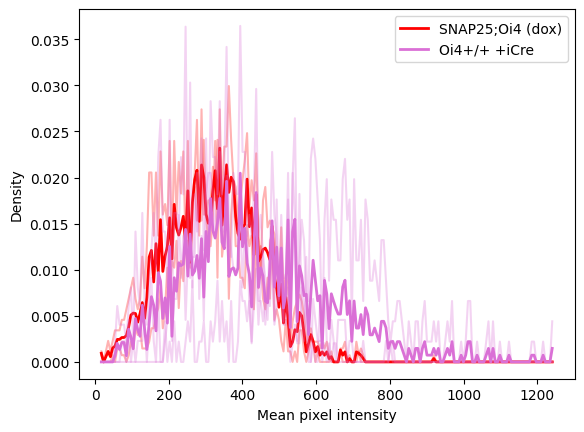

In [58]:
# pan-neuronal
panneuronal_df = brightness_df[brightness_df['gcamp'].isin(panneuronal_order)]
min_brightness = panneuronal_df['brightness'].apply(min).min()
max_brightness = panneuronal_df['brightness'].apply(max).max()
bins = np.linspace(np.floor(min_brightness), np.ceil(max_brightness), 200)
fig, ax = plt.subplots()
for panneuronal in panneuronal_order:
    temp_df = panneuronal_df[panneuronal_df['gcamp'] == panneuronal]
    if len(temp_df) > 0:
        all_dist = []
        for _, row in temp_df.iterrows():
            brightness = np.array(row['brightness'])
            dist = np.histogram(brightness, bins=bins)[0] / len(brightness)
            ax.plot(bins[:-1], dist, alpha=0.3, color=panneuronal_palette[panneuronal])
            all_dist.append(dist)
        ax.plot(bins[:-1], np.mean(all_dist, axis=0), label=panneuronal, color=panneuronal_palette[panneuronal], linewidth=2)
ax.set_xlabel('Mean pixel intensity')
ax.set_ylabel('Density')
ax.legend()

C:\Users\jinho.kim\AppData\Local\Temp\ipykernel_22320\783861807.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['SNAP25;Oi4 (dox)', 'Oi4+/+ +iCre'])


Text(0, 0.5, 'Mean ROI intensity')

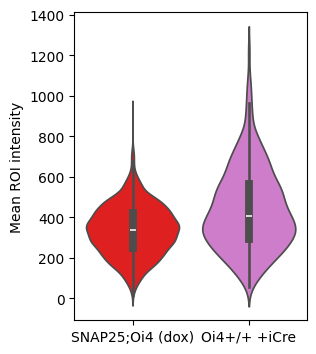

In [59]:
# violin plot of pooled neurons
brightness_snap25 = []
brightness_oi4homo = []
for _, row in panneuronal_df[panneuronal_df['gcamp'] == 'SNAP25;Oi4 (dox)'].iterrows():
    brightness_snap25.append(np.array(row['brightness']))
for _, row in panneuronal_df[panneuronal_df['gcamp'] == 'Oi4+/+ +iCre'].iterrows():
    brightness_oi4homo.append(np.array(row['brightness']))
brightness_snap25 = np.concatenate(brightness_snap25)
brightness_oi4homo = np.concatenate(brightness_oi4homo)
fig, ax = plt.subplots(figsize=(3,4))
sns.violinplot(data=[brightness_snap25, brightness_oi4homo], ax=ax, palette=['r', 'orchid'])
ax.set_xticklabels(['SNAP25;Oi4 (dox)', 'Oi4+/+ +iCre'])
ax.set_ylabel('Mean ROI intensity')



# Density
- Need to have the outlines first
- Also layer distinction?

In [11]:
# draw layer boundaries manually and save them to csv files
# using napari
mouse_id = 753561
hemisphere = 'left'

tissuecyte_dir = Path(r'D:\GCaMP characterization\tissuecyte')
crop_image_path = tissuecyte_dir / f"{mouse_id}_crop_{hemisphere}.tif"
crop_img = tifffile.imread(crop_image_path)
viewer = napari.Viewer()
viewer.add_image(crop_img)

<Image layer 'crop_img' at 0x1e7508d1910>

In [3]:
shapes_fn = r"D:\GCaMP characterization\tissuecyte\741863_crop_left_shapes.csv"
shapes_df = pd.read_csv(shapes_fn)

In [ ]:
# interpolate or extrapolate the line from points to fit exactly to the image shape
from scipy.interpolate import interp1d
def interpolate_shape(shape, image_shape):
    """ Interpolates the shape points to fit exactly to the image shape.
    Args:
        shape (pd.DataFrame): DataFrame containing the shape points.
        image_shape (tuple): Shape of the image (height, width).
    Returns:
        np.ndarray: Interpolated shape points.
    """
    y = shape['axis-0'].values
    x = shape['axis-1'].values
    f = interp1d(x, y, bounds_error=False, fill_value='extrapolate')
    new_x = np.array([0, image_shape[1]])
    new_y = f(new_x)
    return np.column_stack((new_y, new_x))


In [5]:
def make_parallel_lines_df(shapes_df, crop_img):
    parallel_lines_df = pd.DataFrame(columns=['start', 'end'])
    # first, gather slopes and average them
    # also collect middle points
    slopes = []
    mid_points = []
    for i in range(0, len(shapes_df), 2):
        shape1 = shapes_df.iloc[i]
        shape2 = shapes_df.iloc[i + 1]
        
        # calculate slope
        slope = (shape2['axis-0'] - shape1['axis-0']) / (shape2['axis-1'] - shape1['axis-1'])
        slopes.append(slope)
        
        # collect middle points
        mid_x = (shape1['axis-1'] + shape2['axis-1']) / 2
        mid_y = (shape1['axis-0'] + shape2['axis-0']) / 2
        
        midpoint = np.array([[mid_y, mid_x]])
        mid_points.append(midpoint)
    # calculate average slope
    avg_slope = np.mean(slopes)

    # Based on the average slope and midpoints, calculate the parallel lines
    for midpoint in mid_points:
        mid_x = midpoint[0, 1]
        mid_y = midpoint[0, 0]
        
        # calculate start and end points of the parallel line
        start_y = mid_y - avg_slope * mid_x
        end_y = mid_y + avg_slope * (crop_img.shape[1] - mid_x)
        
        temp_df = pd.DataFrame({
            'start': [(start_y, 0)],
            'end': [(end_y, crop_img.shape[1])]
        }, index=[0])
        parallel_lines_df = pd.concat([parallel_lines_df, temp_df], ignore_index=True)
    return parallel_lines_df

In [25]:
lines_df = pd.DataFrame(columns=['start', 'end'])
for index in shapes_df['index'].unique():
    shape = shapes_df.query("index == @index").copy()
    interpolated_shape = interpolate_shape(shape, crop_img.shape)
    lines_df.loc[index] = {'start': interpolated_shape[0], 'end': interpolated_shape[-1]}
# sort lines by the first value of 'start'
lines_df = lines_df.sort_values(by='start', key=lambda x: x.apply(lambda y: y[0]))
lines_df


,start,end
0,"[383.14758708221945, 0.0]","[2.500533652087995, 719.0]"
2,"[556.1794644532035, 0.0]","[151.5333023434689, 719.0]"
3,"[729.9922599730189, 0.0]","[297.92437198030393, 719.0]"
4,"[854.6159257849507, 0.0]","[472.4909368057524, 719.0]"
5,"[1046.421804551694, 0.0]","[638.4309576810924, 719.0]"
1,"[1297.6915275434196, 0.0]","[896.194172773935, 719.0]"


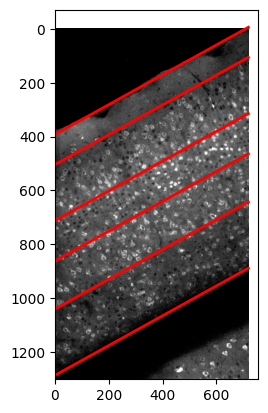

In [94]:
fig, ax = plt.subplots()
ax.imshow(crop_img, cmap='gray', vmax=np.percentile(crop_img, 99.8))
for _, row in parallel_lines_df.iterrows():
    start, end = row['start'], row['end']
    ax.plot([start[1], end[1]], [start[0], end[0]], color='red', linewidth=2)

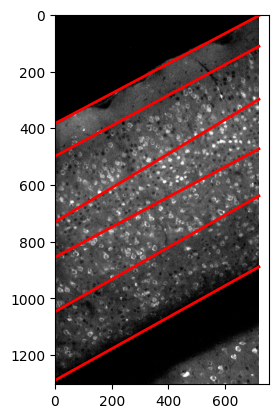

In [93]:
fig, ax = plt.subplots()
ax.imshow(crop_img, cmap='gray', vmax=np.percentile(crop_img, 99.8))
for _, row in lines_df.iterrows():
    start, end = row['start'], row['end']
    ax.plot([start[1], end[1]], [start[0], end[0]], color='red', linewidth=2)

# Saving images
- Example images, zoomed in images, CellPose results (mask overlap)
- Brightness comparison
- Density

In [15]:
mouse_ids = [741863, 753561, 753562, 755212, 758265, 759730, 759731, 767017, 767023, 773630]

In [96]:
mi = 0
mouse_id = mouse_ids[mi]

section_tiff_fn = tissuecyte_dir / f'{mouse_id}.tiff'
section_img = tifffile.imread(section_tiff_fn)
crop_corrds_fn = tissuecyte_dir / f'{mouse_id}_crop_left_coords.npy'
crop_coords = np.load(crop_corrds_fn)
crop_tiff_fn = tissuecyte_dir / f'{mouse_id}_crop_left.tif'
crop_img = tifffile.imread(crop_tiff_fn)
shapes_fn = tissuecyte_dir / f'{mouse_id}_crop_left_shapes.csv'
shapes_df = pd.read_csv(shapes_fn)
# lines_df = pd.DataFrame(columns=['start', 'end'])
# for index in shapes_df['index'].unique():
#     shape = shapes_df.query("index == @index").copy()
#     interpolated_shape = interpolate_shape(shape, crop_img.shape)
#     lines_df.loc[index] = {'start': interpolated_shape[0], 'end': interpolated_shape[-1]}
# # sort lines by the first value of 'start'
# lines_df = lines_df.sort_values(by='start', key=lambda x: x.apply(lambda y: y[0]))
parallel_lines_df = make_parallel_lines_df(shapes_df, crop_img)
parallel_lines_df = parallel_lines_df.sort_values(by='start', key=lambda x: x.apply(lambda y: y[0]))
# CellPose segmentation results
seg_fn = tissuecyte_dir / f'{mouse_id}_crop_left_seg.npy'
cp_results = np.load(seg_fn, allow_pickle=True).item()
valid_roi_ids = get_valid_mask(cp_results)


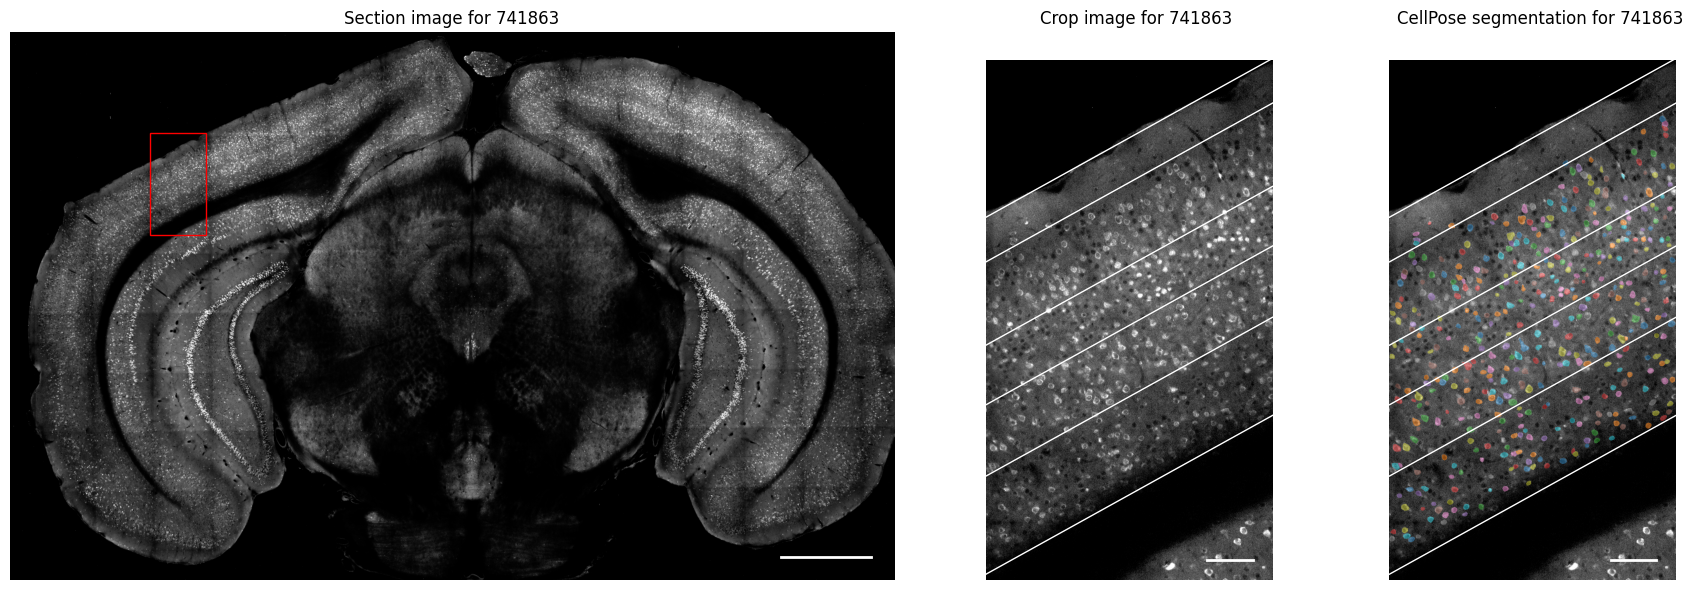

In [99]:
# Draw figures per section
fig, ax = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [2.4, 1, 1]})
ax[0].imshow(section_img, cmap='gray', vmax=np.percentile(section_img, 99.8))
# draw rectangle for the crop area
xmin, xmax, ymin, ymax = crop_coords
rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1, edgecolor='red', facecolor='none')
ax[0].add_patch(rect)
ax[0].set_title(f'Section image for {mouse_id}')
ax[0].axis('off')
# add scale bar on the bottom right corner
scale_bar_length = 1000/0.875  # 1 mm in pixels
scale_bar_y_pos = section_img.shape[0] - 300
scale_bar_x_pos = section_img.shape[1] - scale_bar_length - 300
ax[0].plot([scale_bar_x_pos, scale_bar_x_pos + scale_bar_length], 
           [scale_bar_y_pos, scale_bar_y_pos], color='white', linewidth=2)

ax[1].imshow(crop_img, cmap='gray', vmax=np.percentile(crop_img, 99.8))
ax[1].set_title(f'Crop image for {mouse_id}')
for _, row in parallel_lines_df.iterrows():
    start, end = row['start'], row['end']
    ax[1].plot([start[1], end[1]], [start[0], end[0]], color='white', linewidth=1)
ax[1].axis('off')
# add scale bar of 100 um
scale_bar_length = 100 / 0.875  # in pixels
scale_bar_y_pos = crop_img.shape[0] - 50
scale_bar_x_pos = crop_img.shape[1] - scale_bar_length - 50
ax[1].plot([scale_bar_x_pos, scale_bar_x_pos + scale_bar_length], 
           [scale_bar_y_pos, scale_bar_y_pos], color='white', linewidth=2)

cmap = plt.get_cmap('tab10')
ax[2].imshow(crop_img, cmap='gray', vmax=np.percentile(crop_img, 99.8))
for roi_id in valid_roi_ids:
    roi_mask = cp_results['masks'] == roi_id
    contour = find_contours(roi_mask, level=0.5)[0]
    contour = contour[:, [1, 0]]
    random_color = cmap(np.random.rand())
    polygon = Polygon(contour, closed=True, edgecolor='none', facecolor=random_color, alpha=0.5)
    ax[2].add_patch(polygon)
ax[2].axis('off')
ax[2].plot([scale_bar_x_pos, scale_bar_x_pos + scale_bar_length], 
           [scale_bar_y_pos, scale_bar_y_pos], color='white', linewidth=2)
for _, row in parallel_lines_df.iterrows():
    start, end = row['start'], row['end']
    ax[2].plot([start[1], end[1]], [start[0], end[0]], color='white', linewidth=1)
ax[2].set_title(f'CellPose segmentation for {mouse_id}')
fig.tight_layout()

In [6]:
def get_valid_mask(cp_results):
    num_rois = cp_results['masks'].max()
    
    edge_mask = np.zeros(cp_results['masks'].shape, dtype=bool)
    edge_mask[0,:] = True
    edge_mask[-1,:] = True
    edge_mask[:,0] = True
    edge_mask[:,-1] = True

    brightness = []
    valid_roi_ids = []
    for roi_id in range(1, num_rois + 1):
        roi_mask = cp_results['masks'] == roi_id
        # pass if overlap with edge mask
        if np.any(roi_mask & edge_mask):
            continue
        # pass if too small (equivalent to 4 um in diameter, 1 pixel = 0.875 um)
        if roi_mask.sum() < (4/0.875/2)**2 * np.pi:
            continue
        valid_roi_ids.append(roi_id)
    return np.array(valid_roi_ids)

C:\Users\jinho.kim\AppData\Local\Temp\ipykernel_32036\2764153733.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


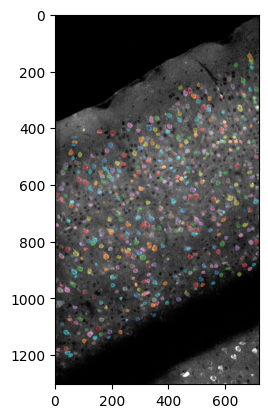

In [74]:


cmap = plt.get_cmap('tab10')

seg_fn = tissuecyte_dir / f'{mouse_id}_crop_left_seg.npy'
cp_results = np.load(seg_fn, allow_pickle=True).item()
valid_roi_ids = get_valid_mask(cp_results)
fig, ax = plt.subplots()
ax.imshow(crop_img, cmap='gray', vmax=np.percentile(crop_img, 99.8))
for roi_id in valid_roi_ids:
    roi_mask = cp_results['masks'] == roi_id
    contour = find_contours(roi_mask, level=0.5)[0]
    contour = contour[:, [1, 0]]
    random_color = cmap(np.random.rand())
    polygon = Polygon(contour, closed=True, edgecolor='none', facecolor=random_color, alpha=0.5)
    ax.add_patch(polygon)
    # ax.contour(roi_mask, colors='red', linewidths=0.5)

    


## save images for all mice

In [17]:
tc_link.gcamp.unique()

array(['Slc32a1;Oi1', 'Slc32a1;Oi4', 'SNAP25;Oi4 (dox)', 'Oi4+/+ +iCre',
       'Oi1+/- +iCre', 'Slc17a7;Oi1 (dox)', 'Cux2-CreERT2;Oi1 (tam)'],
      dtype=object)

In [35]:
def draw_and_save_section_images(mouse_id, gcamp, tissuecyte_dir=Path(r'D:\GCaMP characterization\tissuecyte'),
                                vmin_pctl=0.5, vmax_pctl=99.5):
    gcamp_fn_lut = {'Slc32a1;Oi1': 'slc32a1_oi1',
                    'Slc32a1;Oi4': 'slc32a1_oi4',
                    'SNAP25;Oi4 (dox)': 'snap25_oi4',
                    'Oi4+/+ +iCre': 'oi4_homo'}
    section_tiff_fn = tissuecyte_dir / f'{mouse_id}.tiff'
    section_img = tifffile.imread(section_tiff_fn)
    crop_corrds_fn = tissuecyte_dir / f'{mouse_id}_crop_left_coords.npy'
    crop_coords = np.load(crop_corrds_fn)
    crop_tiff_fn = tissuecyte_dir / f'{mouse_id}_crop_left.tif'
    crop_img = tifffile.imread(crop_tiff_fn)
    shapes_fn = tissuecyte_dir / f'{mouse_id}_crop_left_shapes.csv'
    shapes_df = pd.read_csv(shapes_fn)
    # lines_df = pd.DataFrame(columns=['start', 'end'])
    # for index in shapes_df['index'].unique():
    #     shape = shapes_df.query("index == @index").copy()
    #     interpolated_shape = interpolate_shape(shape, crop_img.shape)
    #     lines_df.loc[index] = {'start': interpolated_shape[0], 'end': interpolated_shape[-1]}
    # # sort lines by the first value of 'start'
    # lines_df = lines_df.sort_values(by='start', key=lambda x: x.apply(lambda y: y[0]))
    parallel_lines_df = make_parallel_lines_df(shapes_df, crop_img)
    parallel_lines_df = parallel_lines_df.sort_values(by='start', key=lambda x: x.apply(lambda y: y[0]))
    # CellPose segmentation results
    seg_fn = tissuecyte_dir / f'{mouse_id}_crop_left_seg.npy'
    cp_results = np.load(seg_fn, allow_pickle=True).item()
    valid_roi_ids = get_valid_mask(cp_results)

    # Draw figures per section
    fig, ax = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [2.4, 1, 1]})
    ax[0].imshow(section_img, cmap='gray',
                vmin=np.percentile(section_img, vmin_pctl),
                vmax=np.percentile(section_img, vmax_pctl))
    # draw rectangle for the crop area
    xmin, xmax, ymin, ymax = crop_coords
    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1, edgecolor='red', facecolor='none')
    ax[0].add_patch(rect)
    ax[0].set_title(f'Section image for {mouse_id} ({gcamp_fn_lut[gcamp]})')
    # add scale bar on the bottom right corner
    scale_bar_length = 1000/0.875  # 1 mm in pixels
    scale_bar_y_pos = section_img.shape[0] - 300
    scale_bar_x_pos = section_img.shape[1] - scale_bar_length - 300
    ax[0].plot([scale_bar_x_pos, scale_bar_x_pos + scale_bar_length], 
            [scale_bar_y_pos, scale_bar_y_pos], color='white', linewidth=2)

    ax[1].imshow(crop_img, cmap='gray',
                vmin=np.percentile(crop_img, vmin_pctl),
                vmax=np.percentile(crop_img, vmax_pctl))
    ax[1].set_title(f'Crop image')
#     for _, row in parallel_lines_df.iterrows():
#         start, end = row['start'], row['end']
#         ax[1].plot([start[1], end[1]], [start[0], end[0]], color='white', linewidth=1)
    
    # add scale bar of 100 um
    scale_bar_length = 100 / 0.875  # in pixels
    scale_bar_y_pos = crop_img.shape[0] - 50
    scale_bar_x_pos = crop_img.shape[1] - scale_bar_length - 50
    ax[1].plot([scale_bar_x_pos, scale_bar_x_pos + scale_bar_length], 
            [scale_bar_y_pos, scale_bar_y_pos], color='white', linewidth=2)

    cmap = plt.get_cmap('jet')
    ax[2].imshow(crop_img, cmap='gray',
            vmin=np.percentile(crop_img, vmin_pctl),
            vmax=np.percentile(crop_img, vmax_pctl))
    for roi_id in valid_roi_ids:
        roi_mask = cp_results['masks'] == roi_id
        contour = find_contours(roi_mask, level=0.5)[0]
        contour = contour[:, [1, 0]]
        random_color = cmap(np.random.rand())
        polygon = Polygon(contour, closed=True, edgecolor='none', facecolor=random_color, alpha=0.5)
        ax[2].add_patch(polygon)
    ax[2].plot([scale_bar_x_pos, scale_bar_x_pos + scale_bar_length], 
            [scale_bar_y_pos, scale_bar_y_pos], color='white', linewidth=2)
    for _, row in parallel_lines_df.iterrows():
        start, end = row['start'], row['end']
        ax[2].plot([start[1], end[1]], [start[0], end[0]], color='white', linewidth=1)
    ax[2].set_title(f'CellPose segmentation')
    for i in range(3):
        ax[i].axis('off')
    for i in range(1,3):
        ax[i].set_xlim(0, crop_img.shape[1])
        ax[i].set_ylim(crop_img.shape[0], 0)  # invert y-axis
    fig.tight_layout()

    save_fn = tissuecyte_dir / f'{mouse_id}({gcamp_fn_lut[gcamp]})_section_images.png'
    fig.savefig(save_fn, dpi=300)
    plt.close(fig)
    

In [37]:
mouse_ids = [741863, 753561, 753562, 755212, 758265, 759730, 759731, 767017, 767023, 773630]
for mouse_id in mouse_ids[6:]:
    gcamp = tc_link.query("mouse_id == @mouse_id")['gcamp'].values[0]
    draw_and_save_section_images(mouse_id, gcamp, tissuecyte_dir=tissuecyte_dir)
    print(f'Section images saved for {mouse_id}')


Section images saved for 759731
Section images saved for 767017
Section images saved for 767023
Section images saved for 773630


## Quantifications
- Full density
- Layer density
- Assign ROIs crossing borders to the layer with more pixels

In [123]:
# getting full cropped section cortical area
mouse_id = 773630
tissuecyte_dir=Path(r'D:\GCaMP characterization\tissuecyte')

crop_tiff_fn = tissuecyte_dir / f'{mouse_id}_crop_left.tif'
crop_img = tifffile.imread(crop_tiff_fn)
shapes_fn = tissuecyte_dir / f'{mouse_id}_crop_left_shapes.csv'
shapes_df = pd.read_csv(shapes_fn)

parallel_lines_df = make_parallel_lines_df(shapes_df, crop_img)
parallel_lines_df = parallel_lines_df.sort_values(by='start', key=lambda x: x.apply(lambda y: y[0]))
# CellPose segmentation results
seg_fn = tissuecyte_dir / f'{mouse_id}_crop_left_seg.npy'
cp_results = np.load(seg_fn, allow_pickle=True).item()
valid_roi_ids = get_valid_mask(cp_results)

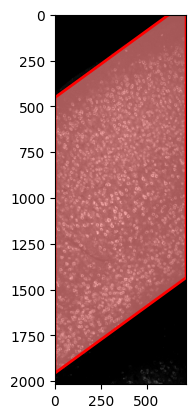

In [104]:
# area within the first and the last line
# draw the parallelogram and overlap with the crop_img, and calculate the area
first_line = parallel_lines_df.iloc[0]
last_line = parallel_lines_df.iloc[-1]
parallelogram = np.array([
    first_line['start'],
    last_line['start'],
    last_line['end'],
    first_line['end'],
    first_line['start']
])
fig, ax = plt.subplots()
ax.imshow(crop_img, cmap='gray', vmax=np.percentile(crop_img, 99.8))
ax.plot(parallelogram[:, 1], parallelogram[:, 0], color='red', linewidth=2)
# fill the parallelogram
ax.fill(parallelogram[:, 1], parallelogram[:, 0], color='red', alpha=0.3)
# calculate the area of the parallelogram

parallelogram_path = matplotlib.path.Path(parallelogram)
# Generate all points in the image as (x, y) pairs
indices = np.indices(crop_img.shape)
coords = np.column_stack((indices[0].ravel(), indices[1].ravel()))

# Check which points are inside the parallelogram
mask = parallelogram_path.contains_points(coords)

# Reshape the mask back to the image shape
mask = mask.reshape(crop_img.shape)

# Calculate the area of the parallelogram
area = np.sum(mask)

ax.imshow(mask, cmap='gray', alpha=0.5)

In [105]:
def mask_between_lines_within_image(line1, line2, img):
    """ Calculate the area between two lines within an image.
    Each line is defined by its start and end points.
    Each start and end is a tuple of (y, x) coordinates.
    Args:
        line1 (dict): First line with 'start' and 'end' keys.
        line2 (dict): Second line with 'start' and 'end' keys.
        img (np.ndarray): The image to calculate the area in.
    Returns:
        float: The mask of the area between the two lines within the image.
    """
    parallelogram = np.array([
        line1['start'],
        line2['start'],
        line2['end'],
        line1['end'],
        line1['start']
    ])
    # Create a path from the parallelogram points
    parallelogram_path = matplotlib.path.Path(parallelogram)
    # Generate all points in the image as (x, y) pairs
    indices = np.indices(img.shape)
    coords = np.column_stack((indices[0].ravel(), indices[1].ravel()))

    # Check which points are inside the parallelogram
    mask = parallelogram_path.contains_points(coords)

    # Reshape the mask back to the image shape
    mask = mask.reshape(img.shape)

    # # Calculate the area of the parallelogram
    # area = np.sum(mask)

    return mask

In [ ]:
# check if mask calculation works for all samples
for mouse_id in mouse_ids:
    crop_tiff_fn = tissuecyte_dir / f'{mouse_id}_crop_left.tif'
    crop_img = tifffile.imread(crop_tiff_fn)
    shapes_fn = tissuecyte_dir / f'{mouse_id}_crop_left_shapes.csv'
    shapes_df = pd.read_csv(shapes_fn)
    parallel_lines_df = make_parallel_lines_df(shapes_df, crop_img)
    parallel_lines_df = parallel_lines_df.sort_values(by='start', key=lambda x: x.apply(lambda y: y[0]))
    
    fig, ax = plt.subplots(1, 2)    
    first_line = parallel_lines_df.iloc[0]
    last_line = parallel_lines_df.iloc[-1]
    mask = mask_between_lines_within_image(first_line, last_line, crop_img)

    ax[0].imshow(crop_img, cmap='gray', vmax=np.percentile(crop_img, 99.8))
    ax[0].imshow(mask, cmap='jet', alpha=0.5)
    ax[0].set_title(f'Full mask for {mouse_id}')

    layered_mask = np.zeros(crop_img.shape, dtype=int)
    for i in range(len(parallel_lines_df)-1):
        line1 = parallel_lines_df.iloc[i]
        line2 = parallel_lines_df.iloc[i + 1]
        mask = mask_between_lines_within_image(line1, line2, crop_img) * (i+1)
        layered_mask += mask
    ax[1].imshow(layered_mask, cmap='jet')

# Checked alright

In [249]:
# calculating density for full and each layer
def get_tissue_masks_from_mouse_id(mouse_id, tissuecyte_dir=Path(r'D:\GCaMP characterization\tissuecyte')):
    crop_tiff_fn = tissuecyte_dir / f'{mouse_id}_crop_left.tif'
    crop_img = tifffile.imread(crop_tiff_fn)
    shapes_fn = tissuecyte_dir / f'{mouse_id}_crop_left_shapes.csv'
    shapes_df = pd.read_csv(shapes_fn)
    parallel_lines_df = make_parallel_lines_df(shapes_df, crop_img)
    parallel_lines_df = parallel_lines_df.sort_values(by='start', key=lambda x: x.apply(lambda y: y[0]))

    full_section_mask = mask_between_lines_within_image(parallel_lines_df.iloc[0], parallel_lines_df.iloc[-1], crop_img)
    layered_masks = []
    for i in range(len(parallel_lines_df)-1):
        line1 = parallel_lines_df.iloc[i]
        line2 = parallel_lines_df.iloc[i + 1]
        mask = mask_between_lines_within_image(line1, line2, crop_img)
        layered_masks.append(mask)
    layered_masks = np.array(layered_masks)
    return full_section_mask, layered_masks



In [246]:
def get_density(num_rois, section_mask, pixel_resolution=0.875, thickness=0.005):
    """ Calculate the density of ROIs within a section mask.
    Args:
        num_rois (int): Number of ROIs within the section mask.
        section_mask (np.ndarray): Binary mask of the section area.
        pixel_resolution (float): Resolution of the image in micrometers per pixel.
        thickness (float): Thickness of the section in millimeters. Optical thickness for serial 2p tomography
    Returns:
        tuple: Density in 2D (ROIs per mm^2) and 3D (ROIs per mm^3).
    """
    section_mask = section_mask.astype(bool)
    area_per_pixel = pixel_resolution ** 2  # um^2 per pixel
    area_full_section = np.sum(section_mask) * area_per_pixel / 1e6 # mm^2
    volume_full_section = area_full_section * 0.005  # assuming 10 um thickness, convert to mm^3
    density_2d = num_rois / area_full_section  # ROIs per mm^2
    density_3d = num_rois / volume_full_section  # ROIs per mm^3
    return density_2d, density_3d

In [250]:
def get_number_of_rois_within_section_mask(valid_roi_masks, section_mask):
    section_mask = section_mask.astype(bool)
    roi_masks_within_section = valid_roi_masks * (section_mask) # section mask can have > 1 values
    roi_ids = np.setdiff1d(np.unique(roi_masks_within_section), [0])
    num_rois_within_section_mask = 0
    for roi_id in roi_ids:
        roi_mask = valid_roi_masks == roi_id
        num_pix = roi_mask.sum()
        num_pix_within_section_mask = np.sum(roi_mask * section_mask)
        if num_pix_within_section_mask / num_pix >= 0.5:
            num_rois_within_section_mask += 1
    return num_rois_within_section_mask

In [251]:
# CellPose segmentation results
seg_fn = tissuecyte_dir / f'{mouse_id}_crop_left_seg.npy'
cp_results = np.load(seg_fn, allow_pickle=True).item()
valid_roi_ids = get_valid_mask(cp_results)

roi_masks = cp_results['masks']
valid_roi_ids = get_valid_mask(cp_results)
valid_roi_masks = np.zeros_like(roi_masks, dtype=np.uint16)
for roi_id in valid_roi_ids:
    roi_mask = roi_masks == roi_id
    valid_roi_masks[roi_mask] = roi_id

full_section_mask, layered_masks = get_tissue_masks_from_mouse_id(mouse_id)

num_rois_within_full_section_mask = get_number_of_rois_within_section_mask(valid_roi_masks, full_section_mask)
num_rois_each_layer_mask = []
for layer_mask in layered_masks:
    num_rois_within_layer_mask = get_number_of_rois_within_section_mask(valid_roi_masks, layer_mask)
    num_rois_each_layer_mask.append(num_rois_within_layer_mask)
assert np.sum(num_rois_each_layer_mask) == num_rois_within_full_section_mask


In [248]:
for num_roi, section_mask in zip([num_rois_within_full_section_mask] + num_rois_each_layer_mask,
                                  [full_section_mask] + list(layered_masks)):
    density_2d, density_3d = get_density(num_roi, section_mask)
    print(f'Number of ROIs: {num_roi}, Number of pixels: {np.sum(section_mask > 0)}, Density 2D: {density_2d:.2f} ROIs/mm^2, Density 3D: {density_3d:.2f} ROIs/mm^3')

Number of ROIs: 454, Number of pixels: 643108, Density 2D: 922.05 ROIs/mm^2, Density 3D: 184410.58 ROIs/mm^3
Number of ROIs: 6, Number of pixels: 80417, Density 2D: 97.45 ROIs/mm^2, Density 3D: 19490.24 ROIs/mm^3
Number of ROIs: 116, Number of pixels: 150071, Density 2D: 1009.59 ROIs/mm^2, Density 3D: 201918.03 ROIs/mm^3
Number of ROIs: 106, Number of pixels: 107383, Density 2D: 1289.30 ROIs/mm^2, Density 3D: 257860.14 ROIs/mm^3
Number of ROIs: 115, Number of pixels: 128432, Density 2D: 1169.52 ROIs/mm^2, Density 3D: 233904.45 ROIs/mm^3
Number of ROIs: 111, Number of pixels: 176805, Density 2D: 820.00 ROIs/mm^2, Density 3D: 163999.43 ROIs/mm^3


In [265]:
# run for all mice and save the results
save_fn = 'tissuecyte_density_results.csv'
results = []
for mouse_id in mouse_ids:
    gcamp = tc_link.query("mouse_id == @mouse_id")['gcamp'].values[0]
    full_section_mask, layered_masks = get_tissue_masks_from_mouse_id(mouse_id, tissuecyte_dir)
    seg_fn = tissuecyte_dir / f'{mouse_id}_crop_left_seg.npy'
    cp_results = np.load(seg_fn, allow_pickle=True).item()
    valid_roi_ids = get_valid_mask(cp_results)

    roi_masks = cp_results['masks']
    valid_roi_masks = np.zeros_like(roi_masks, dtype=np.uint16)
    for roi_id in valid_roi_ids:
        roi_mask = roi_masks == roi_id
        valid_roi_masks[roi_mask] = roi_id

    num_rois_within_full_section_mask = get_number_of_rois_within_section_mask(valid_roi_masks, full_section_mask)
    num_rois_each_layer_mask = []
    for layer_mask in layered_masks:
        num_rois_within_layer_mask = get_number_of_rois_within_section_mask(valid_roi_masks, layer_mask)
        num_rois_each_layer_mask.append(num_rois_within_layer_mask)
    assert np.sum(num_rois_each_layer_mask) == num_rois_within_full_section_mask

    layer_names = ['All', 'L1', 'L2/3', 'L4', 'L5', 'L6']
    for num_roi, section_mask, layer_name in zip([num_rois_within_full_section_mask] + num_rois_each_layer_mask,
                                    [full_section_mask] + list(layered_masks), layer_names):
        density_2d, density_3d = get_density(num_roi, section_mask)
        num_pixels = np.sum(section_mask > 0)
        results.append({
            'mouse_id': mouse_id,
            'gcamp': gcamp,
            'layer': layer_name,
            'num_rois': num_roi,
            'num_pixels': num_pixels,
            'density_2d': density_2d,
            'density_3d': density_3d
        })
results = pd.DataFrame(results)
results.to_csv(tissuecyte_dir / save_fn, index=False)

In [287]:
results = pd.read_csv(tissuecyte_dir / save_fn)

<Axes: xlabel='layer', ylabel='density_2d'>

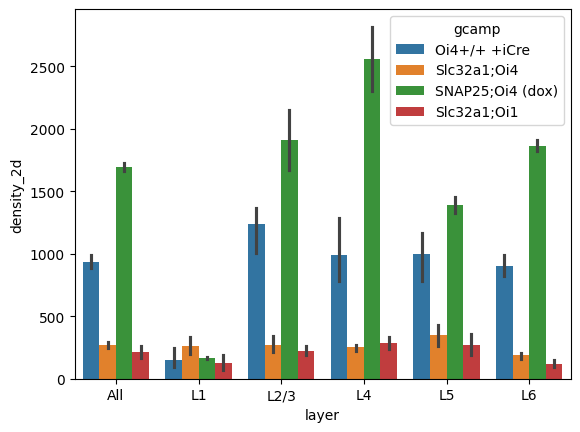

In [288]:
# draw figures
fig, ax = plt.subplots()
sns.barplot(data=results, x='layer', y='density_2d', hue='gcamp', ax=ax)

In [266]:
inhib_order

['Slc32a1;Oi1', 'Slc32a1;Oi4']

In [285]:
inhib_df

,gcamp,mouse_id,brightness
0,Slc32a1;Oi1,767017,"[1893.5875, 1139.5497076023391, 1143.162162162..."
1,Slc32a1;Oi1,767023,"[703.7028985507246, 1995.4697986577182, 1369.0..."
2,Slc32a1;Oi4,753561,"[204.43333333333334, 61.96363636363636, 93.775..."
3,Slc32a1;Oi4,753562,"[148.6504854368932, 247.98445595854923, 354.37..."
4,Slc32a1;Oi4,758265,"[165.05729166666666, 161.74534161490683, 62.38..."


Text(0, 0.5, 'Density (ROIs/mm$^2$)')

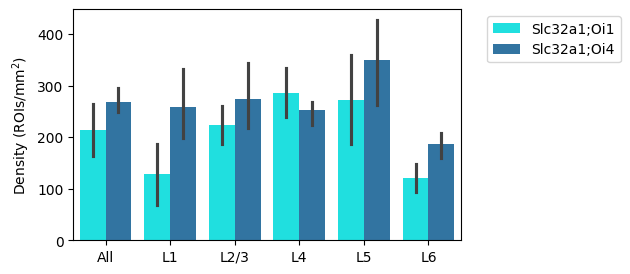

In [291]:
inhib_df = results.query('gcamp in @inhib_order').copy()
fig, ax = plt.subplots(figsize=(5,3))
sns.barplot(data=inhib_df, x='layer', y='density_2d', hue='gcamp', ax=ax, palette=inhib_palette,
hue_order= inhib_order)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('')
ax.set_ylabel('Density (ROIs/mm$^2$)')

Text(0, 0.5, 'Density (ROIs/mm$^2$)')

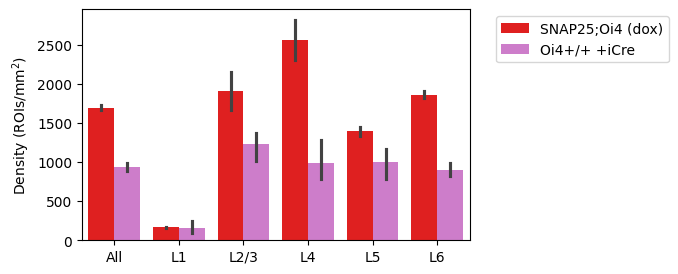

In [294]:
panneuronal_df = results.query('gcamp in @panneuronal_order').copy()
fig, ax = plt.subplots(figsize=(5,3))
sns.barplot(data=panneuronal_df, x='layer', y='density_2d', hue='gcamp', ax=ax, palette=panneuronal_palette,
            hue_order=panneuronal_order)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('')
ax.set_ylabel('Density (ROIs/mm$^2$)')

# Dev codes

In [42]:
path = '/allen/programs/mindscope/production/learning/prod3/0534353296-0046_1413290723/'
print(Path(path))

\allen\programs\mindscope\production\learning\prod3\0534353296-0046_1413290723


In [11]:
fn = r"\\allen\programs\mindscope\production\learning\prod3\0534353977-0046_1417601979\0534353977-0046.jp2"
with rasterio.open(fn) as src:
    img = src.read()
# takes about 2 minutes to load one image

c:\Users\jinho.kim\Anaconda3\envs\allenvisb\lib\site-packages\rasterio\__init__.py:333: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


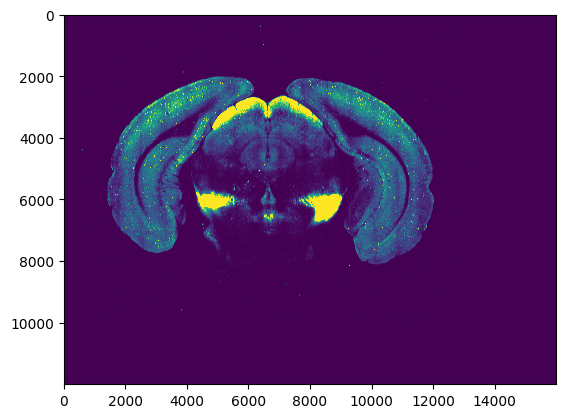

In [18]:
vmax = np.percentile(img[1], 99)
fig, ax = plt.subplots()
ax.imshow(img[1], vmax=vmax)


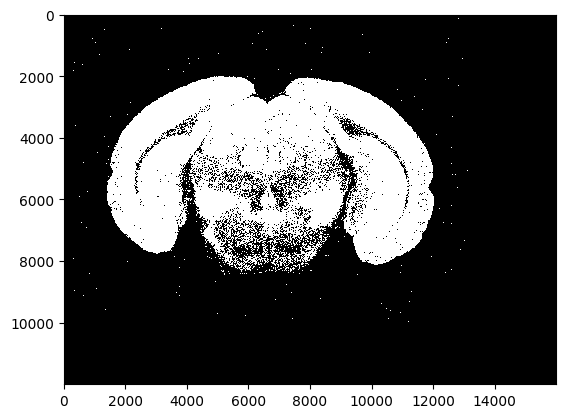

In [28]:
thresholded_image = img[1] > np.percentile(img[1], 50) *1.1
fig, ax = plt.subplots()
ax.imshow(thresholded_image, cmap='gray', interpolation='nearest')

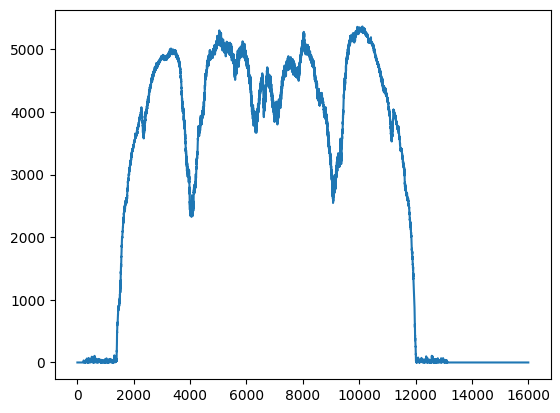

In [29]:
plt.plot(thresholded_image.sum(axis=0))

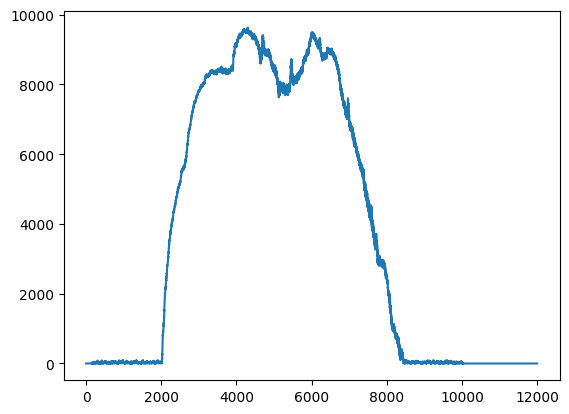

In [47]:
plt.plot(thresholded_image.sum(axis=1))

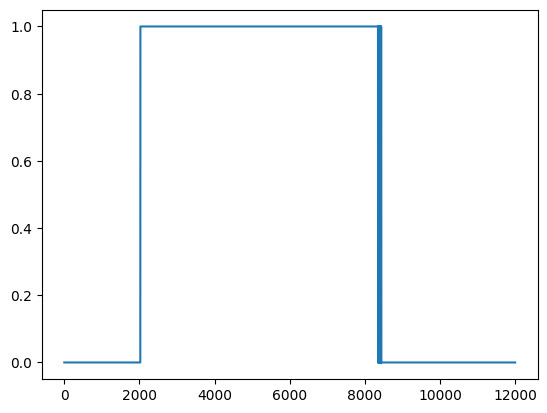

In [54]:
threshold = np.std(np.diff(thresholded_image.sum(axis=1))) * 5
thresholed_twice = thresholded_image.sum(axis=1) > threshold
fig, ax = plt.subplots()
ax.plot(thresholed_twice)

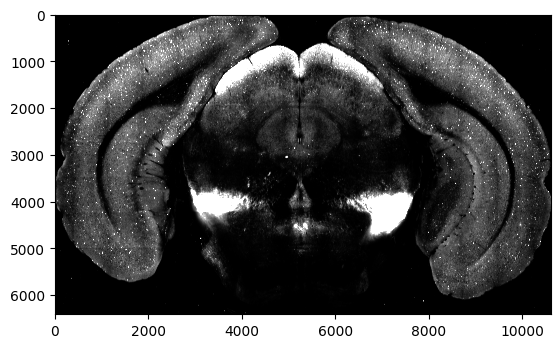

In [55]:
thresholded_image = img[1] > np.percentile(img[1], 50) *1.1
x_threshold = np.std(np.diff(thresholded_image.sum(axis=0))) * 5
x_thresholed_twice = thresholded_image.sum(axis=0) > x_threshold

x_min = np.where(x_thresholed_twice)[0][0]
x_max = np.where(x_thresholed_twice)[0][-1]

y_threshold = np.std(np.diff(thresholded_image.sum(axis=1))) * 5
y_thresholed_twice = thresholded_image.sum(axis=1) > y_threshold

y_min = np.where(y_thresholed_twice)[0][0]
y_max = np.where(y_thresholed_twice)[0][-1]

plt.imshow(img[1][y_min:y_max, x_min:x_max], vmax=vmax, cmap='gray')


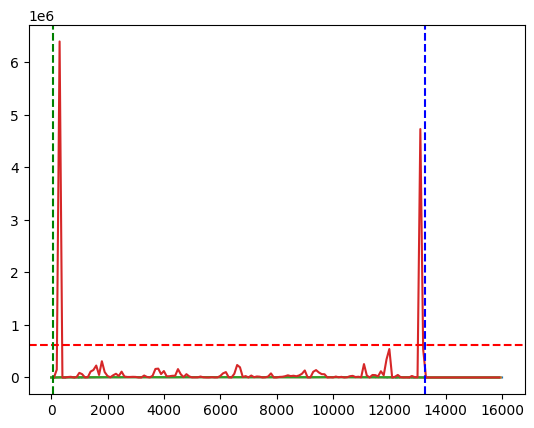

In [85]:
temp = thresholded_image.sum(axis=0)
window_size = 50
skip_size = 100
xpoints = np.arange(len(temp))
# Smoothing and downsampling
smoothed = np.convolve(temp, np.ones(window_size) / window_size, mode='valid')
downsampled = smoothed[::skip_size]
ds_diff = np.diff(downsampled)**2
diff_std = np.std(ds_diff)
x_min = (np.where(ds_diff > diff_std)[0][0]-1) * skip_size - window_size
x_max = (np.where(ds_diff > diff_std)[0][-1] + 2) * skip_size + window_size

fig, ax = plt.subplots()
ax.plot(temp, label='Original')
ax.plot(smoothed, label='Smoothed')
ax.plot(xpoints[::skip_size], downsampled, label='Downsampled')
ax.plot(xpoints[::skip_size][1:], ds_diff, label='Difference')
ax.axhline(diff_std, color='red', linestyle='--', label='Std Dev of Differences')
ax.axvline(x_min, color='green', linestyle='--', label='x_min')
ax.axvline(x_max, color='blue', linestyle='--', label='x_max')

In [71]:
def find_tissue_edges(image, smoothing_window_size=100, downsample_size=100):
    for i in range(2):
        temp = image.sum(axis=i)
        smoothed = np.convolve(temp, np.ones(smoothing_window_size) / smoothing_window_size, mode='valid')
        downsampled = smoothed[::downsample_size]
        ds_diff = np.diff(downsampled)**2
        diff_std = np.std(ds_diff)
    
        temp_min = (np.where(ds_diff > diff_std)[0][0]-1) * downsample_size - smoothing_window_size
        temp_max = (np.where(ds_diff > diff_std)[0][-1] + 2) * downsample_size + smoothing_window_size

        if i == 0:
            x_min, x_max = temp_min, temp_max
        else:
            y_min, y_max = temp_min, temp_max

    return (x_min, x_max), (y_min, y_max)
    

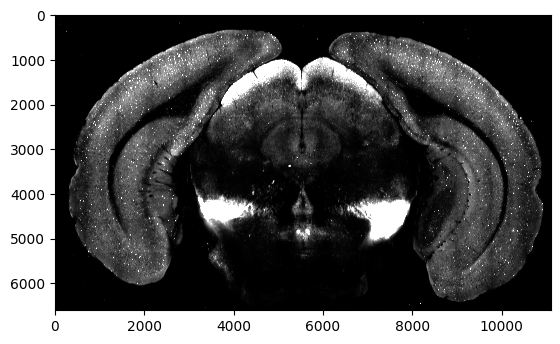

In [72]:
(x_min, x_max), (y_min, y_max) = find_tissue_edges(thresholded_image)
fig, ax = plt.subplots()
ax.imshow(img[1][y_min:y_max, x_min:x_max], vmax=vmax, cmap='gray')

In [74]:
# save as a tiff file
save_dir = Path(r'D:\GCaMP characterization\tissuecyte')
save_dir.mkdir(parents=True, exist_ok=True)
save_fn = save_dir / '0534353977-0046_1417601979.tiff'
with rasterio.open(save_fn, 'w', driver='GTiff', height=y_max-y_min, width=x_max-x_min,
                   count=1, dtype=img.dtype) as dst:
    dst.write(img[1][y_min:y_max, x_min:x_max], 1)

# save downsampled png
downsampled_img = img[1][y_min:y_max, x_min:x_max][::10, ::10]
downsampled_fn = save_dir / '0534353977-0046_1417601979_downsampled.png'
plt.imsave(downsampled_fn, downsampled_img, cmap='gray', vmin=0, vmax=vmax)
